<a href="https://colab.research.google.com/github/sanialamofficial/22-48445-3_mid_labtask/blob/master/otoscopic_classification_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Importing Liberies

In [2]:
import os
import copy
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader, Dataset
from torchvision import transforms as T
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.backbone_utils import resnet_fpn_backbone
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torch.optim.lr_scheduler import ReduceLROnPlateau

from PIL import Image
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_recall_fscore_support
)

# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


# 2. Load and Explore Dataset

In [3]:
from google.colab import files

print("Please choose your downloaded dataset .rar file:")
uploaded = files.upload()
rar_filename = list(uploaded.keys())[0]
print(f"Successfully uploaded: {rar_filename}")

Please choose your downloaded dataset .rar file:


Saving Datos.rar to Datos.rar
Successfully uploaded: Datos.rar


In [4]:
# Install extraction dependencies quietly
!apt-get install -y unrar > /dev/null
!pip install patool > /dev/null

import patoolib
import os

output_dir = "./Datos_extracted"
os.makedirs(output_dir, exist_ok=True)

print(f"Extracting {rar_filename}...")
patoolib.extract_archive(rar_filename, outdir=output_dir)
print("Extraction complete!")

INFO patool: Extracting Datos.rar ...
INFO patool: running '/usr/bin/unrar' 'x' '-kb' '-or' '--' '/content/Datos.rar'
INFO patool: ... Datos.rar extracted to `./Datos_extracted'.


Extracting Datos.rar...
Extraction complete!


In [5]:
import os

EXPECTED_CLASSES = [
    "Chronic otitis media",
    "Earwax plug",
    "Myringosclerosis",
    "Normal"
]

train_root = None
for root, dirs, files in os.walk(output_dir):
    if set(EXPECTED_CLASSES).issubset(set(dirs)):
        train_root = root
        break

if train_root is None:
    train_root = output_dir

print("Dataset Root Path:", train_root)

detected_classes = sorted([
    d for d in os.listdir(train_root)
    if os.path.isdir(os.path.join(train_root, d)) and not d.startswith('.')
])

print("\nDetected Classes & Image Counts:")
total_images = 0
for cls in detected_classes:
    cls_path = os.path.join(train_root, cls)
    count = len([f for f in os.listdir(cls_path) if f.lower().endswith((".jpg", ".jpeg", ".png"))])
    total_images += count
    status = "✓" if cls in EXPECTED_CLASSES else "⚠"
    print(f"{status} {cls}: {count} images")

print(f"\nTotal Verified Images: {total_images}")

Dataset Root Path: ./Datos_extracted/Datos/Training-validation

Detected Classes & Image Counts:
✓ Chronic otitis media: 180 images
✓ Earwax plug: 180 images
✓ Myringosclerosis: 180 images
✓ Normal: 180 images

Total Verified Images: 720


In [6]:
# ============================================================
# 4. Create Base Dataset
# ============================================================

class OtoscopicDataset(Dataset):

    def __init__(
        self,
        root_dir,
        image_paths=None,
        labels=None,
        categories=None,
        class_to_idx=None,
        transform=None
    ):

        self.root_dir = root_dir
        self.transform = transform

        if image_paths is not None:

            self.image_paths = image_paths
            self.labels = labels
            self.categories = categories
            self.class_to_idx = class_to_idx

        else:

            self.categories = sorted([
                d for d in os.listdir(root_dir)
                if os.path.isdir(
                    os.path.join(root_dir, d)
                )
            ])

            # Faster R-CNN uses 0 as background,
            # so disease classes start from 1.
            self.class_to_idx = {
                cls: i + 1
                for i, cls in enumerate(self.categories)
            }

            self.image_paths = []
            self.labels = []

            for cls in self.categories:

                cls_path = os.path.join(
                    root_dir,
                    cls
                )

                for img in os.listdir(cls_path):

                    if img.lower().endswith(
                        (".jpg", ".jpeg", ".png")
                    ):

                        self.image_paths.append(
                            os.path.join(
                                cls_path,
                                img
                            )
                        )

                        self.labels.append(
                            self.class_to_idx[cls]
                        )

    def __getitem__(self, idx):

        img = Image.open(
            self.image_paths[idx]
        ).convert("RGB")

        if self.transform is not None:
            img_tensor = self.transform(img)
        else:
            img_tensor = T.ToTensor()(img)

        # Fixed tympanic membrane region used
        # by the original pipeline.
        target = {
            "boxes": torch.tensor(
                [[100, 100, 540, 540]],
                dtype=torch.float32
            ),

            "labels": torch.tensor(
                [self.labels[idx]],
                dtype=torch.int64
            )
        }

        return img_tensor, target

    def __len__(self):
        return len(self.image_paths)

In [7]:
# ============================================================
# 5. Inspect Dataset
# ============================================================

dataset = OtoscopicDataset(train_root)

print("Total images:", len(dataset))
print("Classes:", dataset.categories)
print("Class mapping:", dataset.class_to_idx)

print("\nFirst 10 samples:")

for i in range(min(10, len(dataset))):

    print(
        i,
        "->",
        os.path.basename(dataset.image_paths[i]),
        "|",
        dataset.labels[i]
    )

Total images: 720
Classes: ['Chronic otitis media', 'Earwax plug', 'Myringosclerosis', 'Normal']
Class mapping: {'Chronic otitis media': 1, 'Earwax plug': 2, 'Myringosclerosis': 3, 'Normal': 4}

First 10 samples:
0 -> o27.jpg | 1
1 -> o81.jpg | 1
2 -> o29.jpg | 1
3 -> o96.jpg | 1
4 -> o68.jpg | 1
5 -> o146.jpg | 1
6 -> o4.jpg | 1
7 -> o148.jpg | 1
8 -> o45.jpg | 1
9 -> o133.jpg | 1


# 3. Cleaning

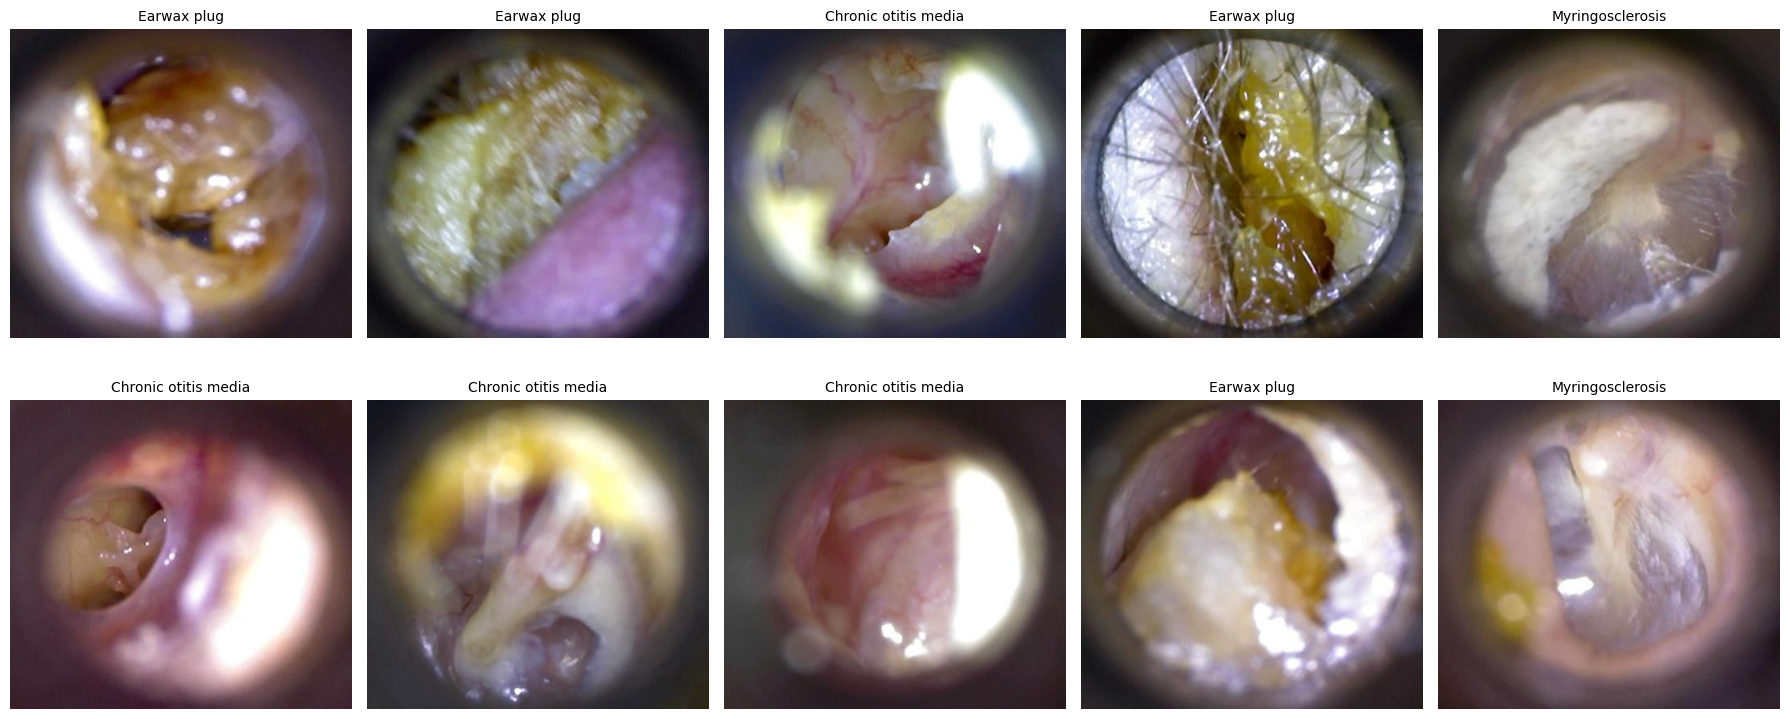

In [8]:
# ============================================================
# 6. Visualize Random Dataset Samples
# ============================================================

fig, axes = plt.subplots(
    2, 5,
    figsize=(18, 8)
)

indices = np.random.choice(
    len(dataset),
    10,
    replace=False
)

idx_to_class = {
    v: k
    for k, v in dataset.class_to_idx.items()
}

for ax, idx in zip(axes.flat, indices):

    img = Image.open(
        dataset.image_paths[idx]
    ).convert("RGB")

    label = dataset.labels[idx]

    ax.imshow(img)

    ax.set_title(
        idx_to_class[label],
        fontsize=10
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

In [9]:
# ============================================================
# 2. Cleaning
# Cell 6 — Image Integrity Check
# ============================================================

valid_image_paths = []
invalid_image_paths = []

supported_extensions = (".jpg", ".jpeg", ".png")

for cls in detected_classes:

    class_path = os.path.join(train_root, cls)

    for filename in os.listdir(class_path):

        if not filename.lower().endswith(supported_extensions):
            continue

        image_path = os.path.join(class_path, filename)

        try:
            with Image.open(image_path) as img:
                img.verify()

            valid_image_paths.append(image_path)

        except Exception as e:
            invalid_image_paths.append(
                (image_path, str(e))
            )

print("============================================")
print("IMAGE INTEGRITY CHECK")
print("============================================")

print(f"Total images found : {len(valid_image_paths) + len(invalid_image_paths)}")
print(f"Valid images       : {len(valid_image_paths)}")
print(f"Invalid images     : {len(invalid_image_paths)}")

if len(invalid_image_paths) == 0:
    print("\n✓ No corrupted or unreadable images found.")
else:
    print("\n⚠ Invalid images:")

    for path, error in invalid_image_paths:
        print(path, "->", error)

IMAGE INTEGRITY CHECK
Total images found : 720
Valid images       : 720
Invalid images     : 0

✓ No corrupted or unreadable images found.


In [10]:
# ============================================================
# Cell 7 — Exact Duplicate Detection
# ============================================================

import hashlib
from collections import defaultdict

def calculate_md5(image_path):

    hash_md5 = hashlib.md5()

    with open(image_path, "rb") as f:

        for chunk in iter(
            lambda: f.read(4096),
            b""
        ):
            hash_md5.update(chunk)

    return hash_md5.hexdigest()


hash_groups = defaultdict(list)

for image_path in tqdm(
    valid_image_paths,
    desc="Checking exact duplicates"
):

    file_hash = calculate_md5(image_path)

    hash_groups[file_hash].append(image_path)


exact_duplicate_groups = {
    h: paths
    for h, paths in hash_groups.items()
    if len(paths) > 1
}

exact_duplicate_count = sum(
    len(paths) - 1
    for paths in exact_duplicate_groups.values()
)

print("============================================")
print("EXACT DUPLICATE ANALYSIS")
print("============================================")

print(
    f"Unique image groups : {len(hash_groups)}"
)

print(
    f"Duplicate groups    : {len(exact_duplicate_groups)}"
)

print(
    f"Duplicate images    : {exact_duplicate_count}"
)


if len(exact_duplicate_groups) == 0:

    print("\n✓ No exact duplicate images found.")

else:

    print("\n⚠ Exact duplicate groups found:\n")

    for i, (file_hash, paths) in enumerate(
        exact_duplicate_groups.items(),
        start=1
    ):

        print(f"Group {i}:")

        for path in paths:
            print("  ", path)

        print()

Checking exact duplicates: 100%|██████████| 720/720 [00:00<00:00, 8021.56it/s]

EXACT DUPLICATE ANALYSIS
Unique image groups : 719
Duplicate groups    : 1
Duplicate images    : 1

⚠ Exact duplicate groups found:

Group 1:
   ./Datos_extracted/Datos/Training-validation/Chronic otitis media/o103.jpg
   ./Datos_extracted/Datos/Training-validation/Chronic otitis media/o99.jpg



In [11]:
# ============================================================
# Cell 8 — Create Clean Dataset
# ============================================================

clean_image_paths = []
removed_duplicate_paths = []

# ------------------------------------------------------------
# Keep one image from each exact-duplicate group
# ------------------------------------------------------------

duplicate_members = set()

for paths in exact_duplicate_groups.values():

    # Keep the first image
    representative = paths[0]

    clean_image_paths.append(representative)

    # Remove the remaining exact duplicates
    for duplicate_path in paths[1:]:

        removed_duplicate_paths.append(
            duplicate_path
        )

    duplicate_members.update(paths)


# ------------------------------------------------------------
# Add images that are not duplicates
# ------------------------------------------------------------

for image_path in valid_image_paths:

    if image_path not in duplicate_members:

        clean_image_paths.append(image_path)


print("============================================")
print("CLEAN DATASET SUMMARY")
print("============================================")

print(f"Original valid images : {len(valid_image_paths)}")
print(f"Removed exact duplicates : {len(removed_duplicate_paths)}")
print(f"Clean images : {len(clean_image_paths)}")
print(f"Invalid images : {len(invalid_image_paths)}")

CLEAN DATASET SUMMARY
Original valid images : 720
Removed exact duplicates : 1
Clean images : 719
Invalid images : 0


In [12]:
# ============================================================
# Cell 9 — Clean Dataset Class Distribution
# ============================================================

clean_class_counts = {}

for cls in detected_classes:

    count = sum(
        1
        for path in clean_image_paths
        if os.path.basename(
            os.path.dirname(path)
        ) == cls
    )

    clean_class_counts[cls] = count


print("============================================")
print("CLEAN DATASET — CLASS DISTRIBUTION")
print("============================================")

for cls, count in clean_class_counts.items():

    print(
        f"{cls:<25} : {count}"
    )

print("--------------------------------------------")
print(
    f"{'Total':<25} : {len(clean_image_paths)}"
)

CLEAN DATASET — CLASS DISTRIBUTION
Chronic otitis media      : 179
Earwax plug               : 180
Myringosclerosis          : 180
Normal                    : 180
--------------------------------------------
Total                     : 719


# 3. split

In [13]:
# ============================================================
# 3. Split
# Cell 10 — Stratified 70/15/15 Train/Validation/Test Split
# ============================================================

# Create labels corresponding to the cleaned image paths

path_to_label = {
    path: dataset.labels[dataset.image_paths.index(path)]
    for path in dataset.image_paths
}

clean_labels = [
    path_to_label[path]
    for path in clean_image_paths
]

# ------------------------------------------------------------
# First split:
# 70% Training
# 30% Temporary
# ------------------------------------------------------------

train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    clean_image_paths,
    clean_labels,
    test_size=0.30,
    stratify=clean_labels,
    random_state=SEED
)

# ------------------------------------------------------------
# Second split:
# 15% Validation
# 15% Test
# ------------------------------------------------------------

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.50,
    stratify=temp_labels,
    random_state=SEED
)

print("============================================")
print("DATASET SPLIT")
print("============================================")

print(f"Total cleaned images : {len(clean_image_paths)}")
print(f"Training images      : {len(train_paths)}")
print(f"Validation images    : {len(val_paths)}")
print(f"Test images          : {len(test_paths)}")

DATASET SPLIT
Total cleaned images : 719
Training images      : 503
Validation images    : 108
Test images          : 108


In [14]:
# ============================================================
# Cell 11 — Verify Class Distribution After Split
# ============================================================

idx_to_class = {
    v: k
    for k, v in dataset.class_to_idx.items()
}

def get_class_distribution(labels):

    distribution = {}

    for class_idx in dataset.class_to_idx.values():

        distribution[idx_to_class[class_idx]] = labels.count(
            class_idx
        )

    return distribution


train_distribution = get_class_distribution(train_labels)
val_distribution = get_class_distribution(val_labels)
test_distribution = get_class_distribution(test_labels)

print("============================================")
print("CLASS DISTRIBUTION AFTER STRATIFIED SPLIT")
print("============================================")

print("\nTraining:")
for cls, count in train_distribution.items():
    print(f"{cls:<25}: {count}")

print("\nValidation:")
for cls, count in val_distribution.items():
    print(f"{cls:<25}: {count}")

print("\nTest:")
for cls, count in test_distribution.items():
    print(f"{cls:<25}: {count}")

CLASS DISTRIBUTION AFTER STRATIFIED SPLIT

Training:
Chronic otitis media     : 125
Earwax plug              : 126
Myringosclerosis         : 126
Normal                   : 126

Validation:
Chronic otitis media     : 27
Earwax plug              : 27
Myringosclerosis         : 27
Normal                   : 27

Test:
Chronic otitis media     : 27
Earwax plug              : 27
Myringosclerosis         : 27
Normal                   : 27


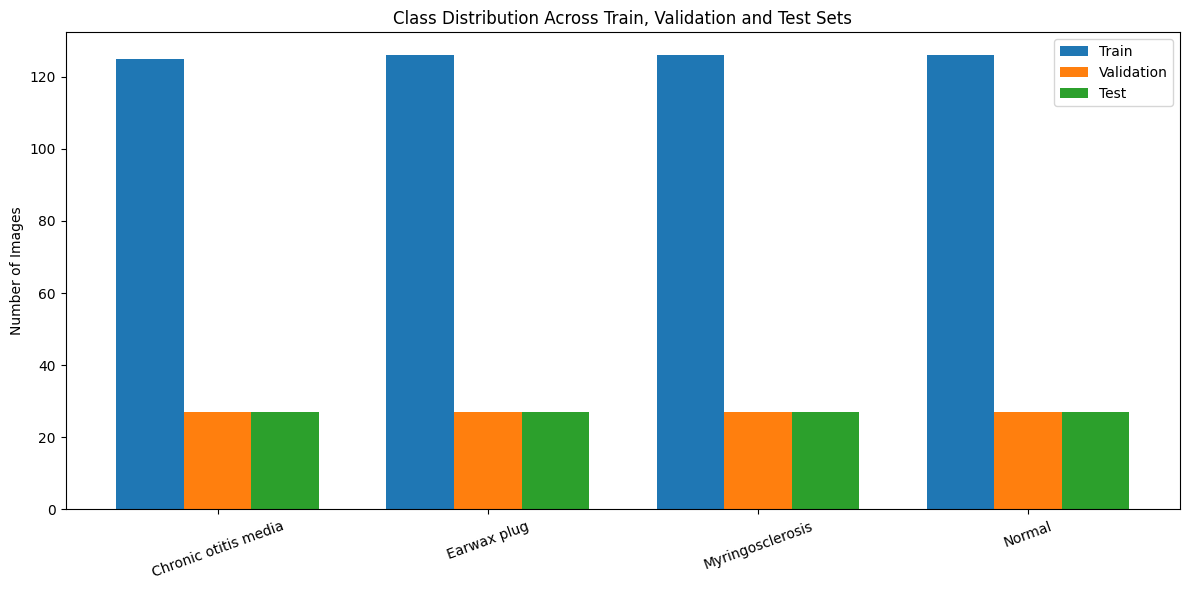

In [15]:
# ============================================================
# Cell 12 — Visualize Train/Validation/Test Distribution
# ============================================================

classes = list(dataset.class_to_idx.keys())

train_counts = [
    train_distribution[cls]
    for cls in classes
]

val_counts = [
    val_distribution[cls]
    for cls in classes
]

test_counts = [
    test_distribution[cls]
    for cls in classes
]

x = np.arange(len(classes))
width = 0.25

plt.figure(figsize=(12, 6))

plt.bar(
    x - width,
    train_counts,
    width,
    label="Train"
)

plt.bar(
    x,
    val_counts,
    width,
    label="Validation"
)

plt.bar(
    x + width,
    test_counts,
    width,
    label="Test"
)

plt.xticks(
    x,
    classes,
    rotation=20
)

plt.ylabel("Number of Images")
plt.title("Class Distribution Across Train, Validation and Test Sets")

plt.legend()
plt.tight_layout()
plt.show()

# 4. Augmentation

In [16]:
# ============================================================
# Cell 13 — Training, Validation and Test Transforms
# ============================================================

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# ------------------------------------------------------------
# Training Transform
# ------------------------------------------------------------

train_transform = T.Compose([

    T.Resize((640, 640)),

    # Geometric augmentation
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=15),

    # Appearance augmentation
    T.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.3,
        hue=0.05
    ),

    T.RandomAutocontrast(p=0.5),

    # Mild blur to reduce pixel-level memorization
    T.GaussianBlur(
        kernel_size=(5, 9),
        sigma=(0.1, 1.0)
    ),

    T.ToTensor(),

    # ImageNet normalization
    T.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])


# ------------------------------------------------------------
# Validation Transform
# No random augmentation
# ------------------------------------------------------------

val_transform = T.Compose([

    T.Resize((640, 640)),

    T.ToTensor(),

    T.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])


# ------------------------------------------------------------
# Test Transform
# No random augmentation
# ------------------------------------------------------------

test_transform = T.Compose([

    T.Resize((640, 640)),

    T.ToTensor(),

    T.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])


print("✓ Training augmentation configured")
print("✓ Validation preprocessing configured")
print("✓ Test preprocessing configured")

✓ Training augmentation configured
✓ Validation preprocessing configured
✓ Test preprocessing configured


In [17]:
# ============================================================
# Cell 14 — Create Train, Validation and Test Datasets
# ============================================================

train_data = OtoscopicDataset(
    root_dir=train_root,
    image_paths=train_paths,
    labels=train_labels,
    categories=dataset.categories,
    class_to_idx=dataset.class_to_idx,
    transform=train_transform
)

val_data = OtoscopicDataset(
    root_dir=train_root,
    image_paths=val_paths,
    labels=val_labels,
    categories=dataset.categories,
    class_to_idx=dataset.class_to_idx,
    transform=val_transform
)

test_data = OtoscopicDataset(
    root_dir=train_root,
    image_paths=test_paths,
    labels=test_labels,
    categories=dataset.categories,
    class_to_idx=dataset.class_to_idx,
    transform=test_transform
)

print("============================================")
print("DATASET OBJECTS")
print("============================================")

print(f"Training set   : {len(train_data)}")
print(f"Validation set : {len(val_data)}")
print(f"Test set       : {len(test_data)}")

DATASET OBJECTS
Training set   : 503
Validation set : 108
Test set       : 108


In [18]:
# ============================================================
# Cell 15 — DataLoaders
# ============================================================

BATCH_SIZE = 8

train_loader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=lambda x: tuple(zip(*x))
)

val_loader = DataLoader(
    val_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=lambda x: tuple(zip(*x))
)

test_loader = DataLoader(
    test_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=lambda x: tuple(zip(*x))
)

print("✓ Train DataLoader created")
print("✓ Validation DataLoader created")
print("✓ Test DataLoader created")
print(f"Batch size: {BATCH_SIZE}")

✓ Train DataLoader created
✓ Validation DataLoader created
✓ Test DataLoader created
Batch size: 8


# 5. Model

In [19]:
# ============================================================
# 5. Model
# Cell 16 — Faster R-CNN with ResNet-101 + FPN
# ============================================================

class TwoMLPHeadWithDropout(nn.Module):
    """
    Faster R-CNN ROI box head with dropout
    for reducing overfitting.
    """

    def __init__(
        self,
        in_channels,
        representation_size,
        dropout_p=0.5
    ):
        super().__init__()

        self.fc6 = nn.Linear(
            in_channels,
            representation_size
        )

        self.dropout1 = nn.Dropout(
            p=dropout_p
        )

        self.fc7 = nn.Linear(
            representation_size,
            representation_size
        )

        self.dropout2 = nn.Dropout(
            p=dropout_p
        )

    def forward(self, x):

        x = x.flatten(start_dim=1)

        x = F.relu(self.fc6(x))
        x = self.dropout1(x)

        x = F.relu(self.fc7(x))
        x = self.dropout2(x)

        return x

In [20]:
# ============================================================
# Cell 17 — Build Faster R-CNN Model
# ============================================================

NUM_CLASSES = len(dataset.categories) + 1
# +1 = Background class

backbone = resnet_fpn_backbone(
    backbone_name="resnet101",
    weights="ResNet101_Weights.DEFAULT",
    trainable_layers=1
)

model = FasterRCNN(
    backbone=backbone,
    num_classes=NUM_CLASSES,
    image_mean=IMAGENET_MEAN,
    image_std=IMAGENET_STD
)

# ------------------------------------------------------------
# Replace default ROI box head with dropout version
# ------------------------------------------------------------

in_channels = model.roi_heads.box_head.fc6.in_features
representation_size = model.roi_heads.box_head.fc7.out_features

model.roi_heads.box_head = TwoMLPHeadWithDropout(
    in_channels=in_channels,
    representation_size=representation_size,
    dropout_p=0.5
)

# ------------------------------------------------------------
# Replace classifier predictor
# ------------------------------------------------------------

model.roi_heads.box_predictor = FastRCNNPredictor(
    representation_size,
    NUM_CLASSES
)

model = model.to(device)

print("✓ Faster R-CNN model created")
print("✓ Backbone: ResNet-101 + FPN")
print("✓ Trainable backbone layers: 1")
print("✓ Dropout: 0.5")
print("✓ Number of classes:", NUM_CLASSES)

Downloading: "https://download.pytorch.org/models/resnet101-cd907fc2.pth" to /root/.cache/torch/hub/checkpoints/resnet101-cd907fc2.pth


100%|██████████| 171M/171M [00:03<00:00, 50.5MB/s]


✓ Faster R-CNN model created
✓ Backbone: ResNet-101 + FPN
✓ Trainable backbone layers: 1
✓ Dropout: 0.5
✓ Number of classes: 5


In [21]:
# ============================================================
# Cell 18 — Model Parameter Analysis
# ============================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

frozen_params = total_params - trainable_params

print("============================================")
print("MODEL PARAMETER SUMMARY")
print("============================================")

print(f"Total parameters      : {total_params:,}")
print(f"Trainable parameters  : {trainable_params:,}")
print(f"Frozen parameters     : {frozen_params:,}")

print(
    f"Trainable percentage  : "
    f"{100 * trainable_params / total_params:.2f}%"
)

MODEL PARAMETER SUMMARY
Total parameters      : 60,254,440
Trainable parameters  : 32,801,832
Frozen parameters     : 27,452,608
Trainable percentage  : 54.44%


# 6. Training

In [22]:
# ============================================================

# Cell 19 — Optimizer and Learning Rate Scheduler
# ============================================================

optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=5e-5,
    weight_decay=1e-2
)

scheduler = ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

print("✓ Optimizer: AdamW")
print("✓ Learning rate: 5e-5")
print("✓ Weight decay: 1e-2")
print("✓ Scheduler: ReduceLROnPlateau")

✓ Optimizer: AdamW
✓ Learning rate: 5e-5
✓ Weight decay: 1e-2
✓ Scheduler: ReduceLROnPlateau


In [23]:
# ============================================================
# Cell 20 — Training Configuration
# ============================================================

NUM_EPOCHS = 10

EARLY_STOPPING_PATIENCE = 3

GRAD_CLIP_NORM = 5.0

best_val_loss = float("inf")
best_model_state = None

patience_counter = 0

history = {
    "train_loss": [],
    "val_loss": [],
    "learning_rate": []
}

print("============================================")
print("TRAINING CONFIGURATION")
print("============================================")

print(f"Maximum epochs          : {NUM_EPOCHS}")
print(f"Early stopping patience : {EARLY_STOPPING_PATIENCE}")
print(f"Gradient clipping norm  : {GRAD_CLIP_NORM}")

TRAINING CONFIGURATION
Maximum epochs          : 10
Early stopping patience : 3
Gradient clipping norm  : 5.0


In [24]:
# ============================================================
# Cell 21 — Training Loop
# ============================================================

for epoch in range(NUM_EPOCHS):

    # ========================================================
    # TRAINING
    # ========================================================

    model.train()

    running_train_loss = 0.0

    train_loop = tqdm(
        train_loader,
        desc=f"Epoch {epoch + 1}/{NUM_EPOCHS} [Train]"
    )

    for imgs, targets in train_loop:

        imgs = [
            img.to(device)
            for img in imgs
        ]

        targets = [
            {
                k: v.to(device)
                for k, v in target.items()
            }
            for target in targets
        ]

        # Forward pass
        loss_dict = model(
            imgs,
            targets
        )

        # Total Faster R-CNN loss
        losses = sum(
            loss
            for loss in loss_dict.values()
        )

        # Clear previous gradients
        optimizer.zero_grad()

        # Backpropagation
        losses.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            GRAD_CLIP_NORM
        )

        # Update weights
        optimizer.step()

        running_train_loss += losses.item()

        train_loop.set_postfix(
            loss=f"{losses.item():.4f}"
        )

    train_loss = (
        running_train_loss /
        len(train_loader)
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    model.train()

    running_val_loss = 0.0

    with torch.no_grad():

        val_loop = tqdm(
            val_loader,
            desc=f"Epoch {epoch + 1}/{NUM_EPOCHS} [Val]"
        )

        for imgs, targets in val_loop:

            imgs = [
                img.to(device)
                for img in imgs
            ]

            targets = [
                {
                    k: v.to(device)
                    for k, v in target.items()
                }
                for target in targets
            ]

            # Faster R-CNN returns losses in train mode
            loss_dict = model(
                imgs,
                targets
            )

            losses = sum(
                loss
                for loss in loss_dict.values()
            )

            running_val_loss += losses.item()

            val_loop.set_postfix(
                loss=f"{losses.item():.4f}"
            )

    val_loss = (
        running_val_loss /
        len(val_loader)
    )


    # ========================================================
    # RECORD HISTORY
    # ========================================================

    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(
        train_loss
    )

    history["val_loss"].append(
        val_loss
    )

    history["learning_rate"].append(
        current_lr
    )


    print("\n--------------------------------------------")

    print(
        f"Epoch {epoch + 1}: "
        f"Train Loss = {train_loss:.4f} | "
        f"Val Loss = {val_loss:.4f} | "
        f"LR = {current_lr:.2e}"
    )


    # ========================================================
    # LEARNING RATE SCHEDULER
    # ========================================================

    scheduler.step(val_loss)


    # ========================================================
    # BEST MODEL CHECKPOINT
    # ========================================================

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        best_model_state = copy.deepcopy(
            model.state_dict()
        )

        torch.save(
            best_model_state,
            "best_model.pt"
        )

        patience_counter = 0

        print(
            "✓ Validation improved — "
            "best model saved."
        )

    else:

        patience_counter += 1

        print(
            f"⚠ No validation improvement "
            f"({patience_counter}/"
            f"{EARLY_STOPPING_PATIENCE})"
        )


    # ========================================================
    # EARLY STOPPING
    # ========================================================

    if patience_counter >= EARLY_STOPPING_PATIENCE:

        print("\nEarly stopping triggered.")

        break


# ============================================================
# RESTORE BEST MODEL
# ============================================================

if best_model_state is not None:

    model.load_state_dict(
        best_model_state
    )

    print(
        "\n✓ Best validation model restored."
    )

print(
    f"Best validation loss: "
    f"{best_val_loss:.4f}"
)

Epoch 1/10 [Val]: 100%|██████████| 14/14 [00:14<00:00,  1.02s/it, loss=0.3001]



--------------------------------------------
Epoch 1: Train Loss = 1.8571 | Val Loss = 0.2639 | LR = 5.00e-05
✓ Validation improved — best model saved.


Epoch 2/10 [Val]: 100%|██████████| 14/14 [00:14<00:00,  1.03s/it, loss=0.2427]



--------------------------------------------
Epoch 2: Train Loss = 0.2672 | Val Loss = 0.2193 | LR = 5.00e-05
✓ Validation improved — best model saved.


Epoch 3/10 [Val]: 100%|██████████| 14/14 [00:14<00:00,  1.03s/it, loss=0.2941]


...


--------------------------------------------
Epoch 8: Train Loss = 0.1746 | Val Loss = 0.1421 | LR = 5.00e-05
✓ Validation improved — best model saved.


Epoch 9/10 [Val]: 100%|██████████| 14/14 [00:14<00:00,  1.03s/it, loss=0.1740]



--------------------------------------------
Epoch 9: Train Loss = 0.1680 | Val Loss = 0.1574 | LR = 5.00e-05
⚠ No validation improvement (1/3)


Epoch 10/10 [Val]: 100%|██████████| 14/14 [00:14<00:00,  1.02s/it, loss=0.1609]



--------------------------------------------
Epoch 10: Train Loss = 0.1575 | Val Loss = 0.1345 | LR = 5.00e-05
✓ Validation improved — best model saved.

✓ Best validation model restored.
Best validation loss: 0.1345


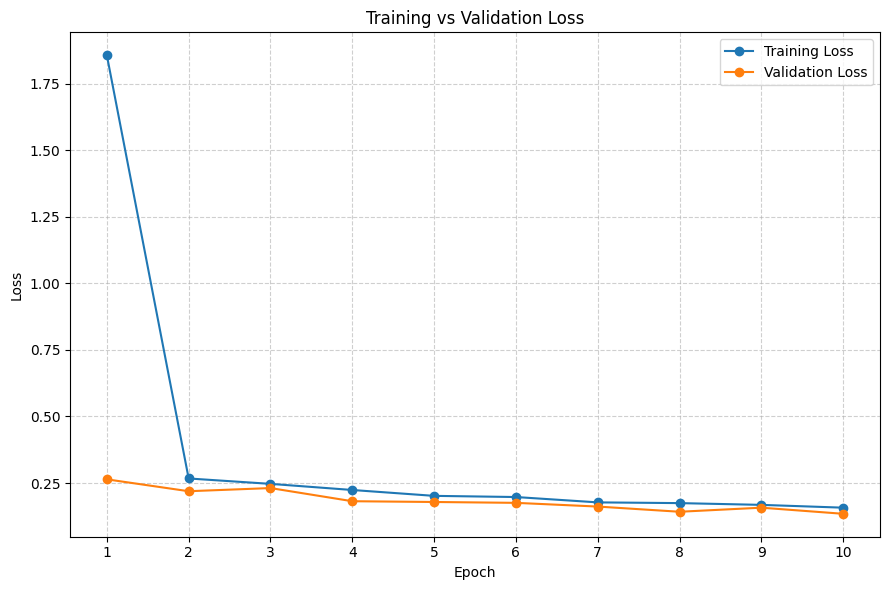

In [25]:
# ============================================================
# Cell 22 — Training and Validation Loss Curves
# ============================================================

epochs_ran = range(
    1,
    len(history["train_loss"]) + 1
)

plt.figure(figsize=(9, 6))

plt.plot(
    epochs_ran,
    history["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs_ran,
    history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Training vs Validation Loss"
)

plt.xticks(
    list(epochs_ran)
)

plt.grid(
    True,
    linestyle="--",
    alpha=0.6
)

plt.legend()

plt.tight_layout()

plt.show()

# 7. Validation

In [26]:
# ============================================================
# Cell 23 — Validation Set Prediction and Metrics
# ============================================================

model.eval()

all_val_preds = []
all_val_labels = []
all_val_scores = []

with torch.no_grad():

    for imgs, targets in tqdm(
        val_loader,
        desc="Validating"
    ):

        imgs = [
            img.to(device)
            for img in imgs
        ]

        outputs = model(imgs)

        for i, output in enumerate(outputs):

            true_label = targets[i]["labels"][0].item()

            all_val_labels.append(true_label)

            # Keep only detected objects
            if len(output["labels"]) > 0:

                best_idx = torch.argmax(
                    output["scores"]
                )

                predicted_label = (
                    output["labels"][best_idx].item()
                )

                prediction_score = (
                    output["scores"][best_idx].item()
                )

            else:

                predicted_label = 0
                prediction_score = 0.0

            all_val_preds.append(
                predicted_label
            )

            all_val_scores.append(
                prediction_score
            )


# ------------------------------------------------------------
# Validation Metrics
# ------------------------------------------------------------

class_indices = list(
    range(1, len(dataset.categories) + 1)
)

print("\n============================================")
print("VALIDATION SET CLASSIFICATION REPORT")
print("============================================")

print(
    classification_report(
        all_val_labels,
        all_val_preds,
        labels=class_indices,
        target_names=dataset.categories,
        digits=4,
        zero_division=0
    )
)

val_accuracy = accuracy_score(
    all_val_labels,
    all_val_preds
)

val_precision, val_recall, val_f1, _ = (
    precision_recall_fscore_support(
        all_val_labels,
        all_val_preds,
        labels=class_indices,
        average="macro",
        zero_division=0
    )
)

print("--------------------------------------------")
print(f"Validation Accuracy      : {val_accuracy:.4f}")
print(f"Validation Macro Precision: {val_precision:.4f}")
print(f"Validation Macro Recall   : {val_recall:.4f}")
print(f"Validation Macro F1       : {val_f1:.4f}")

Validating: 100%|██████████| 14/14 [00:14<00:00,  1.03s/it]


VALIDATION SET CLASSIFICATION REPORT
                      precision    recall  f1-score   support

Chronic otitis media     1.0000    1.0000    1.0000        27
         Earwax plug     1.0000    1.0000    1.0000        27
    Myringosclerosis     0.9643    1.0000    0.9818        27
              Normal     1.0000    0.9630    0.9811        27

            accuracy                         0.9907       108
           macro avg     0.9911    0.9907    0.9907       108
        weighted avg     0.9911    0.9907    0.9907       108

--------------------------------------------
Validation Accuracy      : 0.9907
Validation Macro Precision: 0.9911
Validation Macro Recall   : 0.9907
Validation Macro F1       : 0.9907


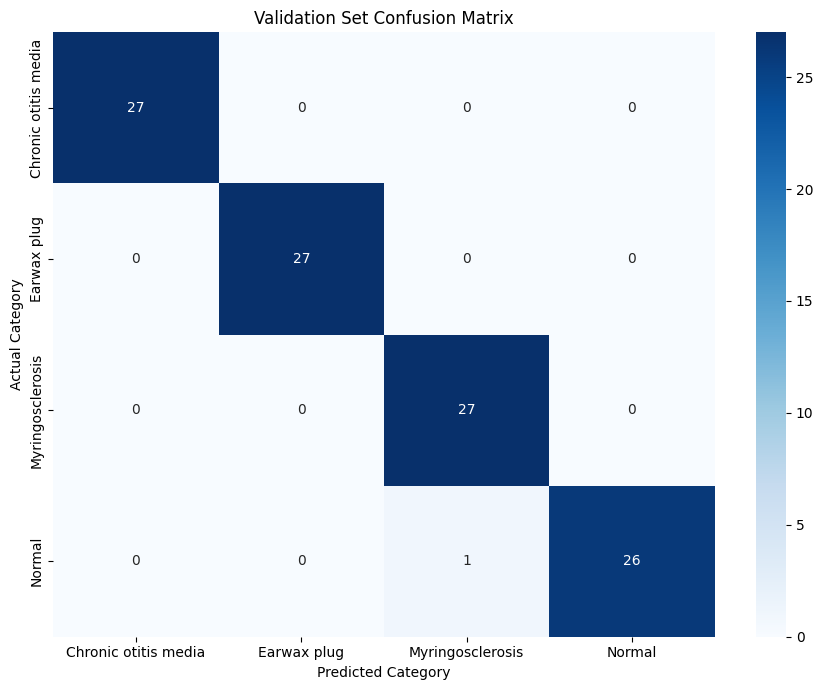

In [27]:
# ============================================================
# Cell 24 — Validation Confusion Matrix
# ============================================================

val_cm = confusion_matrix(
    all_val_labels,
    all_val_preds,
    labels=class_indices
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    val_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=dataset.categories,
    yticklabels=dataset.categories
)

plt.title("Validation Set Confusion Matrix")

plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")

plt.tight_layout()
plt.show()

# 8. Internal Test

In [28]:
# ============================================================

# Cell 25 — Internal Test Evaluation
# ============================================================

model.eval()

all_test_preds = []
all_test_labels = []
all_test_scores = []

with torch.no_grad():

    for imgs, targets in tqdm(
        test_loader,
        desc="Testing"
    ):

        imgs = [
            img.to(device)
            for img in imgs
        ]

        outputs = model(imgs)

        for i, output in enumerate(outputs):

            true_label = targets[i]["labels"][0].item()

            all_test_labels.append(true_label)

            # Select highest-confidence detection
            if len(output["labels"]) > 0:

                best_idx = torch.argmax(
                    output["scores"]
                )

                predicted_label = (
                    output["labels"][best_idx].item()
                )

                prediction_score = (
                    output["scores"][best_idx].item()
                )

            else:

                predicted_label = 0
                prediction_score = 0.0

            all_test_preds.append(
                predicted_label
            )

            all_test_scores.append(
                prediction_score
            )


# ------------------------------------------------------------
# Test Metrics
# ------------------------------------------------------------

class_indices = list(
    range(1, len(dataset.categories) + 1)
)

print("\n============================================")
print("INTERNAL TEST SET CLASSIFICATION REPORT")
print("============================================")

print(
    classification_report(
        all_test_labels,
        all_test_preds,
        labels=class_indices,
        target_names=dataset.categories,
        digits=4,
        zero_division=0
    )
)

test_accuracy = accuracy_score(
    all_test_labels,
    all_test_preds
)

test_precision, test_recall, test_f1, _ = (
    precision_recall_fscore_support(
        all_test_labels,
        all_test_preds,
        labels=class_indices,
        average="macro",
        zero_division=0
    )
)

print("--------------------------------------------")
print(f"Test Accuracy       : {test_accuracy:.4f}")
print(f"Test Macro Precision: {test_precision:.4f}")
print(f"Test Macro Recall   : {test_recall:.4f}")
print(f"Test Macro F1       : {test_f1:.4f}")

Testing: 100%|██████████| 14/14 [00:14<00:00,  1.06s/it]


INTERNAL TEST SET CLASSIFICATION REPORT
                      precision    recall  f1-score   support

Chronic otitis media     0.9310    1.0000    0.9643        27
         Earwax plug     1.0000    0.9630    0.9811        27
    Myringosclerosis     0.9643    1.0000    0.9818        27
              Normal     1.0000    0.9259    0.9615        27

            accuracy                         0.9722       108
           macro avg     0.9738    0.9722    0.9722       108
        weighted avg     0.9738    0.9722    0.9722       108

--------------------------------------------
Test Accuracy       : 0.9722
Test Macro Precision: 0.9738
Test Macro Recall   : 0.9722
Test Macro F1       : 0.9722


## 8.1 internal test confusion matrix

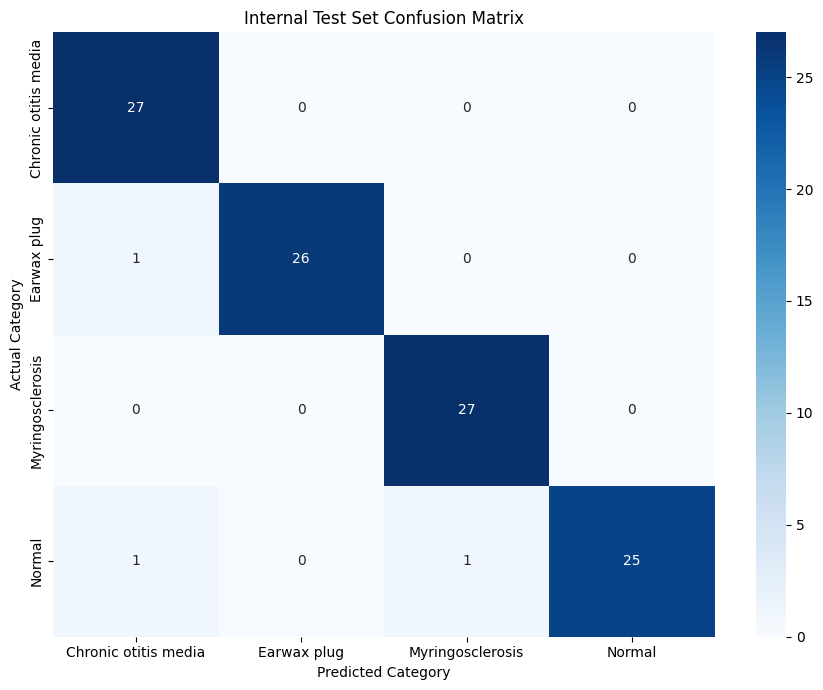

In [29]:
# ============================================================
# Cell 26 — Internal Test Confusion Matrix
# ============================================================

test_cm = confusion_matrix(
    all_test_labels,
    all_test_preds,
    labels=class_indices
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    test_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=dataset.categories,
    yticklabels=dataset.categories
)

plt.title("Internal Test Set Confusion Matrix")

plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")

plt.tight_layout()
plt.show()

# 9. Duplicate Analysis

In [30]:
# ============================================================

# Cell 27 — Generate Perceptual Hashes
# ============================================================

!pip -q install ImageHash

import imagehash

def calculate_phash(image_path):
    """
    Calculate perceptual hash (pHash) for an image.
    """
    with Image.open(image_path) as img:
        return imagehash.phash(
            img.convert("RGB")
        )


print("Calculating perceptual hashes...")

train_hashes = {
    path: calculate_phash(path)
    for path in tqdm(
        train_paths,
        desc="Train"
    )
}

val_hashes = {
    path: calculate_phash(path)
    for path in tqdm(
        val_paths,
        desc="Validation"
    )
}

test_hashes = {
    path: calculate_phash(path)
    for path in tqdm(
        test_paths,
        desc="Test"
    )
}

print("\n✓ Perceptual hashes generated.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 16.4 MB/s eta 0:00:00
Calculating perceptual hashes...


Test: 100%|██████████| 108/108 [00:00<00:00, 460.96it/s]


✓ Perceptual hashes generated.


In [31]:
# ============================================================
# Cell 28 — Train ↔ Validation Near-Duplicate Analysis
# ============================================================

PHASH_THRESHOLD = 5

train_val_duplicates = []

for train_path, train_hash in train_hashes.items():

    for val_path, val_hash in val_hashes.items():

        distance = train_hash - val_hash

        if distance <= PHASH_THRESHOLD:

            train_val_duplicates.append({
                "train": train_path,
                "validation": val_path,
                "distance": distance
            })


print("============================================")
print("TRAIN ↔ VALIDATION DUPLICATE ANALYSIS")
print("============================================")

print(
    f"Near-duplicate pairs: "
    f"{len(train_val_duplicates)}"
)

if len(train_val_duplicates) == 0:

    print("✓ No near-duplicate leakage detected.")

else:

    print("⚠ Near-duplicate pairs detected.")

    for pair in train_val_duplicates[:20]:

        print(
            f"\nDistance: {pair['distance']}"
        )

        print(
            "Train:",
            os.path.basename(pair["train"])
        )

        print(
            "Validation:",
            os.path.basename(pair["validation"])
        )

TRAIN ↔ VALIDATION DUPLICATE ANALYSIS
Near-duplicate pairs: 187
⚠ Near-duplicate pairs detected.

Distance: 4
Train: mi12.jpg
Validation: mi18.jpg

Distance: 0
Train: o22.jpg
Validation: o17.jpg

Distance: 2
Train: mi13.jpg
Validation: mi18.jpg

Distance: 4
Train: e81.jpg
Validation: e87.jpg

Distance: 0
Train: o6.jpg
Validation: o5.jpg

Distance: 2
Train: o93.jpg
Validation: o94.jpg

Distance: 4
Train: e93.jpg
Validation: e92.jpg

Distance: 4
Train: n46.jpg
Validation: n45.jpg

Distance: 4
Train: mi126.jpg
Validation: mi128.jpg

Distance: 4
Train: e125.jpg
Validation: e92.jpg

Distance: 0
Train: o100.jpg
Validation: o102.jpg

Distance: 4
Train: o100.jpg
Validation: o177.jpg

Distance: 0
Train: mi72.jpg
Validation: mi73.jpg

Distance: 2
Train: mi72.jpg
Validation: mi69.jpg

Distance: 2
Train: mi84.jpg
Validation: mi85.jpg

Distance: 4
Train: n12.jpg
Validation: n20.jpg

Distance: 4
Train: n12.jpg
Validation: n21.jpg

Distance: 2
Train: n12.jpg
Validation: n23.jpg

Distance: 2
Train: o2

In [32]:
# ============================================================
# Cell 29 — Train ↔ Test Near-Duplicate Analysis
# ============================================================

train_test_duplicates = []

for train_path, train_hash in train_hashes.items():

    for test_path, test_hash in test_hashes.items():

        distance = train_hash - test_hash

        if distance <= PHASH_THRESHOLD:

            train_test_duplicates.append({
                "train": train_path,
                "test": test_path,
                "distance": distance
            })


print("============================================")
print("TRAIN ↔ TEST DUPLICATE ANALYSIS")
print("============================================")

print(
    f"Near-duplicate pairs: "
    f"{len(train_test_duplicates)}"
)

if len(train_test_duplicates) == 0:

    print("✓ No near-duplicate leakage detected.")

else:

    print("⚠ Near-duplicate pairs detected.")

    for pair in train_test_duplicates[:20]:

        print(
            f"\nDistance: {pair['distance']}"
        )

        print(
            "Train:",
            os.path.basename(pair["train"])
        )

        print(
            "Test:",
            os.path.basename(pair["test"])
        )

TRAIN ↔ TEST DUPLICATE ANALYSIS
Near-duplicate pairs: 160
⚠ Near-duplicate pairs detected.

Distance: 4
Train: mi12.jpg
Test: mi14.jpg

Distance: 0
Train: o22.jpg
Test: o21.jpg

Distance: 2
Train: mi13.jpg
Test: mi14.jpg

Distance: 2
Train: mi23.jpg
Test: mi19.jpg

Distance: 4
Train: n161.jpg
Test: n160.jpg

Distance: 4
Train: o100.jpg
Test: o178.jpg

Distance: 2
Train: mi72.jpg
Test: mi68.jpg

Distance: 4
Train: n12.jpg
Test: n22.jpg

Distance: 4
Train: n12.jpg
Test: n24.jpg

Distance: 4
Train: mi160.jpg
Test: mi159.jpg

Distance: 4
Train: mi25.jpg
Test: mi19.jpg

Distance: 2
Train: mi152.jpg
Test: mi121.jpg

Distance: 4
Train: mi17.jpg
Test: mi14.jpg

Distance: 2
Train: n102.jpg
Test: n105.jpg

Distance: 4
Train: o133.jpg
Test: o134.jpg

Distance: 0
Train: o160.jpg
Test: o161.jpg

Distance: 0
Train: e114.jpg
Test: e115.jpg

Distance: 0
Train: e114.jpg
Test: e110.jpg

Distance: 2
Train: e164.jpg
Test: e165.jpg

Distance: 2
Train: e119.jpg
Test: e117.jpg


In [33]:
# ============================================================
# Cell 30 — Validation ↔ Test Near-Duplicate Analysis
# ============================================================

val_test_duplicates = []

for val_path, val_hash in val_hashes.items():

    for test_path, test_hash in test_hashes.items():

        distance = val_hash - test_hash

        if distance <= PHASH_THRESHOLD:

            val_test_duplicates.append({
                "validation": val_path,
                "test": test_path,
                "distance": distance
            })


print("============================================")
print("VALIDATION ↔ TEST DUPLICATE ANALYSIS")
print("============================================")

print(
    f"Near-duplicate pairs: "
    f"{len(val_test_duplicates)}"
)

if len(val_test_duplicates) == 0:

    print("✓ No near-duplicate leakage detected.")

else:

    print("⚠ Near-duplicate pairs detected.")

    for pair in val_test_duplicates[:20]:

        print(
            f"\nDistance: {pair['distance']}"
        )

        print(
            "Validation:",
            os.path.basename(pair["validation"])
        )

        print(
            "Test:",
            os.path.basename(pair["test"])
        )

VALIDATION ↔ TEST DUPLICATE ANALYSIS
Near-duplicate pairs: 38
⚠ Near-duplicate pairs detected.

Distance: 4
Validation: e155.jpg
Test: e156.jpg

Distance: 0
Validation: n100.jpg
Test: n105.jpg

Distance: 2
Validation: e72.jpg
Test: e71.jpg

Distance: 0
Validation: o9.jpg
Test: o8.jpg

Distance: 2
Validation: n20.jpg
Test: n22.jpg

Distance: 4
Validation: n138.jpg
Test: n139.jpg

Distance: 0
Validation: mi49.jpg
Test: mi30.jpg

Distance: 0
Validation: o17.jpg
Test: o21.jpg

Distance: 4
Validation: o102.jpg
Test: o178.jpg

Distance: 2
Validation: e1.jpg
Test: e3.jpg

Distance: 4
Validation: mi33.jpg
Test: mi44.jpg

Distance: 2
Validation: mi33.jpg
Test: mi45.jpg

Distance: 2
Validation: n21.jpg
Test: n22.jpg

Distance: 2
Validation: e154.jpg
Test: e156.jpg

Distance: 2
Validation: n23.jpg
Test: n22.jpg

Distance: 2
Validation: mi114.jpg
Test: mi115.jpg

Distance: 4
Validation: e53.jpg
Test: e51.jpg

Distance: 0
Validation: e53.jpg
Test: e52.jpg

Distance: 4
Validation: e84.jpg
Test: e83.

In [34]:
# ============================================================
# Cell 31 — Final Duplicate / Leakage Summary
# ============================================================

print("============================================")
print("FINAL DATA LEAKAGE SUMMARY")
print("============================================")

print(
    f"Train ↔ Validation : "
    f"{len(train_val_duplicates)} pairs"
)

print(
    f"Train ↔ Test       : "
    f"{len(train_test_duplicates)} pairs"
)

print(
    f"Validation ↔ Test  : "
    f"{len(val_test_duplicates)} pairs"
)

total_cross_split_duplicates = (
    len(train_val_duplicates)
    + len(train_test_duplicates)
    + len(val_test_duplicates)
)

print("--------------------------------------------")

print(
    f"Total cross-split near-duplicate pairs: "
    f"{total_cross_split_duplicates}"
)

if total_cross_split_duplicates == 0:

    print(
        "\n✓ No cross-split near-duplicate leakage "
        "detected with the selected pHash threshold."
    )

else:

    print(
        "\n⚠ WARNING: Cross-split near-duplicates "
        "were detected."
    )

FINAL DATA LEAKAGE SUMMARY
Train ↔ Validation : 187 pairs
Train ↔ Test       : 160 pairs
Validation ↔ Test  : 38 pairs
--------------------------------------------
Total cross-split near-duplicate pairs: 385

⚠ WARNING: Cross-split near-duplicates were detected.
